Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.
%%SLOAN: major dataset in astronomy

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

Download the SDSS quasara data

In [27]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()
quasars = fetch_dr7_quasar()

# select the first 10000 points
# data = data[:100000] #%%useful trick: trial and error with few data!

z = data['redshift']
quasars = quasars[:10000]
data = quasars['redshift']


- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)

(Hint: `scipy.stats` is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

(Hint: `astropy.cosmology` is another close friend). The best-fit cosmological model from the Plack data is:

In [28]:
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

(array([8.93425258e-03, 3.88902706e-02, 1.01780393e-01, 1.63269109e-01,
        2.22130014e-01, 3.02888639e-01, 3.21633049e-01, 3.06567448e-01,
        3.32319114e-01, 3.47910258e-01, 3.60523319e-01, 3.35472379e-01,
        3.57019691e-01, 3.70158705e-01, 3.75238557e-01, 3.69807933e-01,
        4.05019394e-01, 4.17982356e-01, 4.67034126e-01, 4.55120772e-01,
        4.72990300e-01, 5.30800225e-01, 4.92609550e-01, 4.90333277e-01,
        4.81047590e-01, 4.82625287e-01, 5.52521522e-01, 5.92989691e-01,
        5.45689455e-01, 5.59354825e-01, 5.16959737e-01, 6.06829036e-01,
        5.25368435e-01, 5.07150710e-01, 4.72463711e-01, 3.90129406e-01,
        3.49662459e-01, 3.61049262e-01, 2.99208838e-01, 2.63648297e-01,
        2.20378443e-01, 1.84115854e-01, 1.45575260e-01, 1.48553990e-01,
        1.25430020e-01, 1.09313314e-01, 8.88166750e-02, 7.56784480e-02,
        7.05981818e-02, 6.74449131e-02, 5.83352126e-02, 6.60434604e-02,
        7.98828062e-02, 1.05459319e-01, 9.72257838e-02, 1.112398

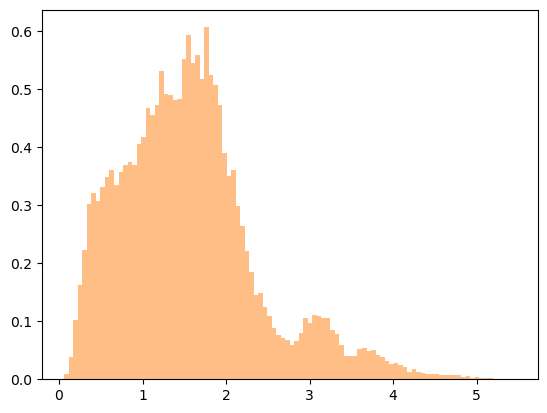

In [29]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Nbins = 100

plt.hist(z, density=True,bins=Nbins, color="C1", histtype='stepfilled', alpha=0.5)

### REJECTION SAMPLING

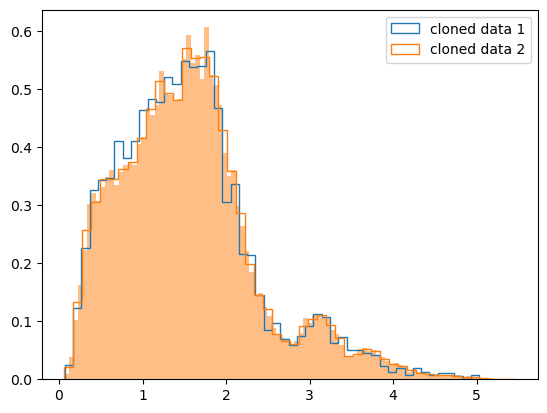

In [30]:
plt.hist(z, density=True,bins=Nbins, color="C1", histtype='stepfilled', alpha=0.5)
counts, bins = np.histogram(z, bins=Nbins, density=True)
maxh = counts.max()

disth = stats.rv_histogram((counts,bins))


N = 100000 # trials
q = np.random.uniform(-10, 30, N) # proposed points
u = np.random.uniform(0, maxh, N) # uniform draws

mask = u<=disth.pdf(q) # assess whether u <= q(x_i)

monte_carlo = q[mask] # reject all points that don't pass, using masking

plt.hist(monte_carlo, bins=50, density=True,histtype='step',label='cloned data 1');

### But scipy has it already implemented 
plt.hist(disth.rvs(size=N),bins=50,density=True,histtype='step',label='cloned data 2');

plt.legend();


### INVERSE TRANSFORM

In [31]:
# "inverting" the histogram
def ecdf(x):

    sorted_data = np.sort(z)  # Sort the predefined data
    # Count how many values are less than or equal to `x`
    count = np.sum(sorted_data <= x)
    # ECDF value is the ratio of count to total number of data points
    return count / len(z)

In [32]:
import scipy.optimize
import tqdm

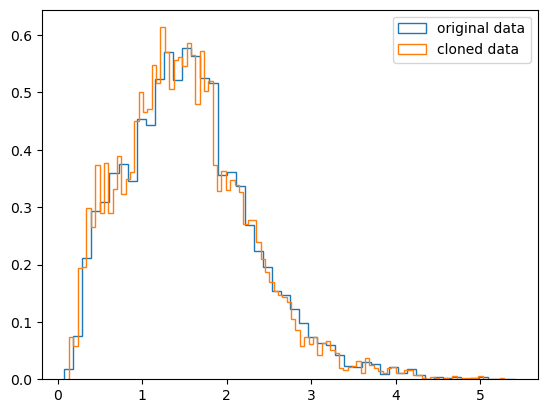

In [33]:
plt.hist(data,bins=50,histtype='step',density=True,label='original data');


# make a simple histogram object
counts, bins = np.histogram(data, bins=50, density=True)
bin_mids = (bins[1:] + bins[:-1]) / 2 # mid location of bins
 
simple_cdf = np.cumsum(counts) / np.sum(counts) # very simply cumulative sum


# set up an interpolation of the inverse cumulative distribution
tck = scipy.interpolate.interp1d(simple_cdf, bin_mids)
# tck = scipy.interpolate.CubicSpline(simple_cdf, bin_mids)


# sample uniformly along the cumulative distribution, and interpolate
# little hack to make sure no points are generated outside interpolation range.
# not ideal
u = np.random.uniform(min(simple_cdf),max(simple_cdf), 10000) 
x_sample = tck(u)

plt.hist(x_sample, bins=100, density=True, histtype='step',label='cloned data');

plt.legend();